# Estudio Comparativo: Bandido de k-Brazos con Distribución Bernoulli

**Asignatura**: Extensiones de Machine Learning — Máster IA (UMU)

---

Estudio comparativo de **ε-greedy**, **UCB1** y **Softmax** sobre bandidos con brazos de distribución **Bernoulli(p)**: cada tirada devuelve **1 (éxito)** o **0 (fracaso)**.

### ¿Por qué Bernoulli es especialmente interesante?

- **Señal muy débil**: cada muestra solo da 1 bit de información (0 o 1). El agente necesita muchas muestras para estimar $p$ con precisión.
- **Recompensas acotadas en [0, 1]**: el valor teórico $c = \sqrt{2}$ de UCB1 es exactamente el derivado para esta situación (desigualdad de Hoeffding para variables acotadas).
- **Caso de uso real**: publicidad online (CTR), tests A/B, diagnóstico médico.

### Hipótesis de partida

1. **UCB1 con c=√2** debería ser especialmente eficiente aquí, ya que la cota de Hoeffding es exacta para Bernoulli.
2. **Softmax necesitará τ muy baja** (≤0.1) porque las recompensas están en [0,1] → los Q estimados serán pequeños.
3. La **convergencia será más lenta** que con Normal: con Bernoulli, la varianza de cada muestra es $p(1-p) \leq 0.25$ pero la información por muestra es mínima.
4. Brazos con **p cercanas** serán difíciles de discriminar → todos los algoritmos tendrán regret alto.

### Diseño experimental

| Parámetro | Valores |
|---|---|
| k (brazos) | 10 |
| Rango de p | [0.1, 0.9] (estándar), [0.4, 0.6] (difícil) |
| Pasos (T) | 1000, 5000 |
| Ejecuciones | 500 |
| Semilla | 42 |

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from arms import ArmBernoulli, Bandit
from algorithms import EpsilonGreedy, UCB1, Softmax
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics
from main import run_experiment

SEED = 42
print("Entorno cargado.")

Entorno cargado.


---
## Experimento 1: Escenario estándar (k=10, p∈[0.1, 0.9], T=1000)

Con probabilidades bien separadas, los brazos deberían ser relativamente fáciles de discriminar. Este es el caso base.

In [2]:
np.random.seed(SEED)

k, steps, runs = 10, 1000, 500
bandit_bern = Bandit(arms=ArmBernoulli.generate_arms(k, p_min=0.1, p_max=0.9))

print("Brazos Bernoulli:")
for i, arm in enumerate(bandit_bern.arms):
    marker = " ★ ÓPTIMO" if i == bandit_bern.optimal_arm else ""
    print(f"  Brazo {i+1}: p = {arm.p:.3f}{marker}")
print(f"\nDiferencia entre el mejor y el segundo: Δ = {bandit_bern.get_expected_value(bandit_bern.optimal_arm) - sorted([a.get_expected_value() for a in bandit_bern.arms])[-2]:.3f}")

algorithms = [
    EpsilonGreedy(k=k, epsilon=0.01),
    EpsilonGreedy(k=k, epsilon=0.1),
    UCB1(k=k, c=np.sqrt(2)),
    Softmax(k=k, tau=0.1),
    Softmax(k=k, tau=0.01),
]

print(f"\nEjecutando {runs} ejecuciones × {steps} pasos...")
rew1, opt1, reg1, arm1 = run_experiment(bandit_bern, algorithms, steps, runs)
print("Completado.")

Brazos Bernoulli:
  Brazo 1: p = 0.400
  Brazo 2: p = 0.861 ★ ÓPTIMO
  Brazo 3: p = 0.686
  Brazo 4: p = 0.579
  Brazo 5: p = 0.225
  Brazo 6: p = 0.146
  Brazo 7: p = 0.793
  Brazo 8: p = 0.581
  Brazo 9: p = 0.666
  Brazo 10: p = 0.116

Diferencia entre el mejor y el segundo: Δ = 0.068

Ejecutando 500 ejecuciones × 1000 pasos...
Completado.


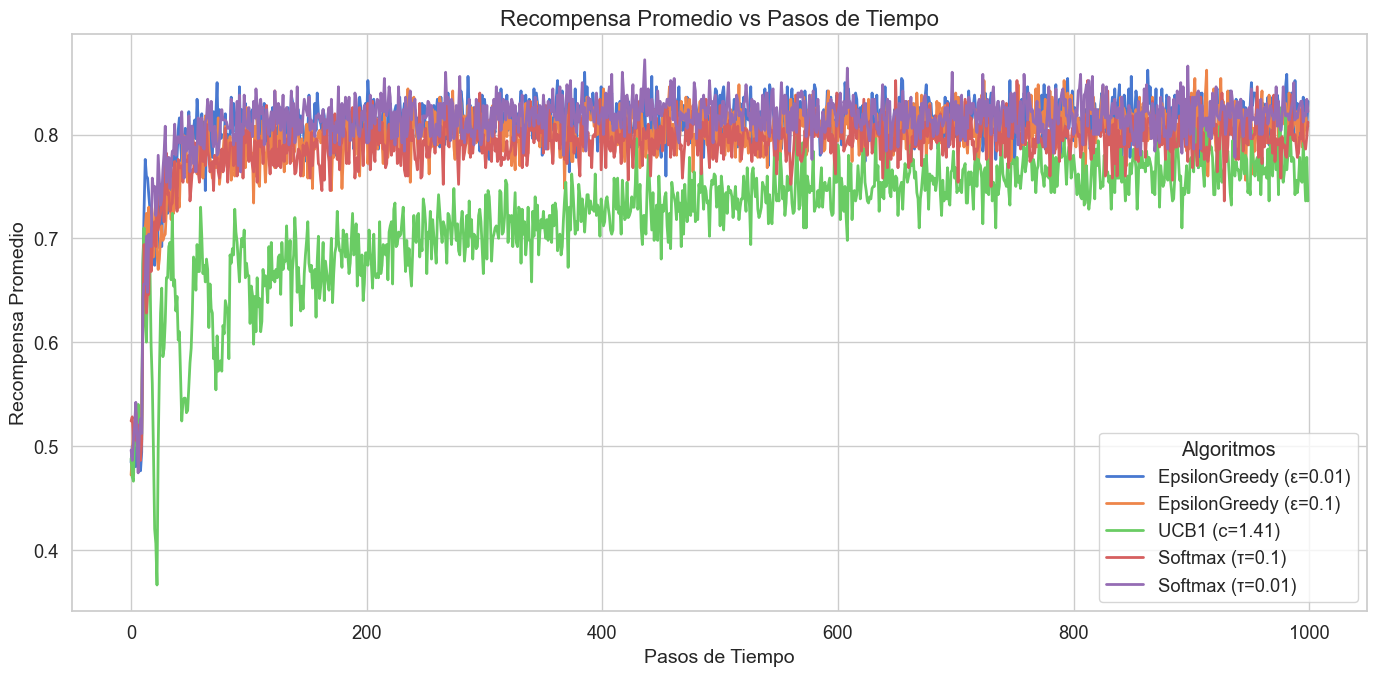

In [3]:
plot_average_rewards(steps, rew1, algorithms)

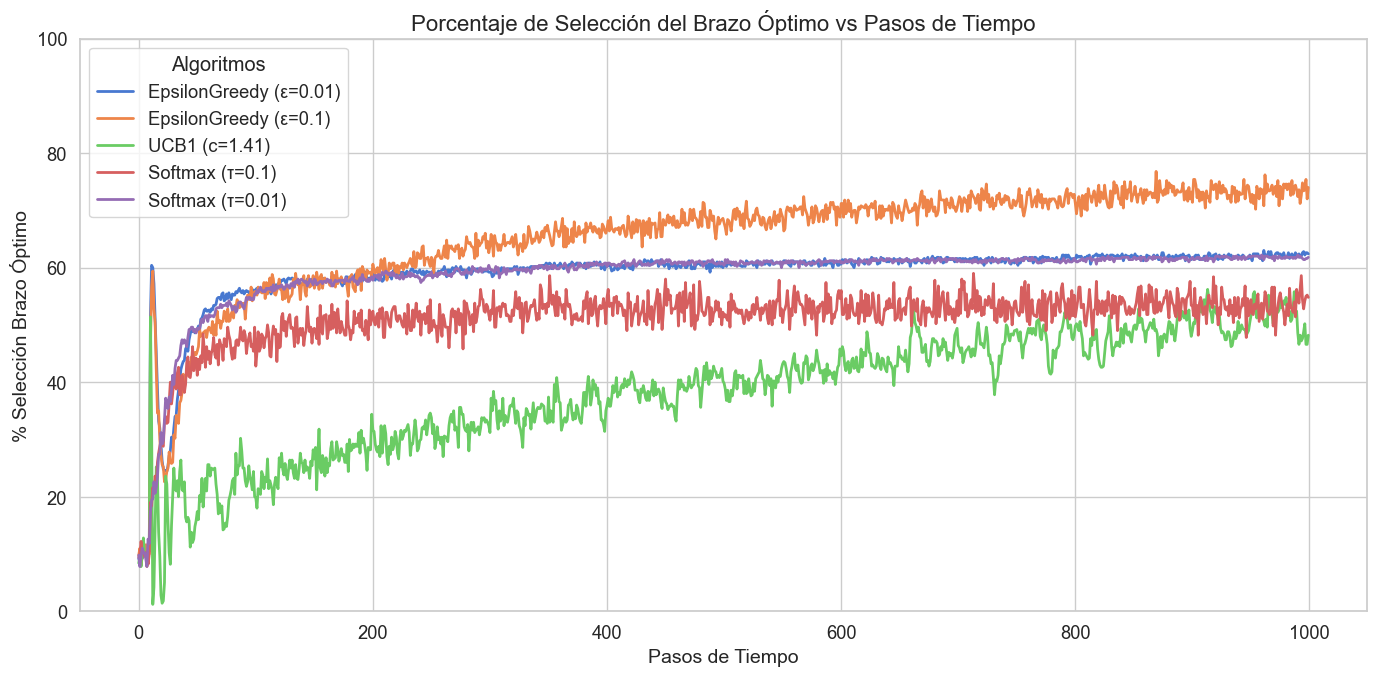

In [4]:
plot_optimal_selections(steps, opt1, algorithms)

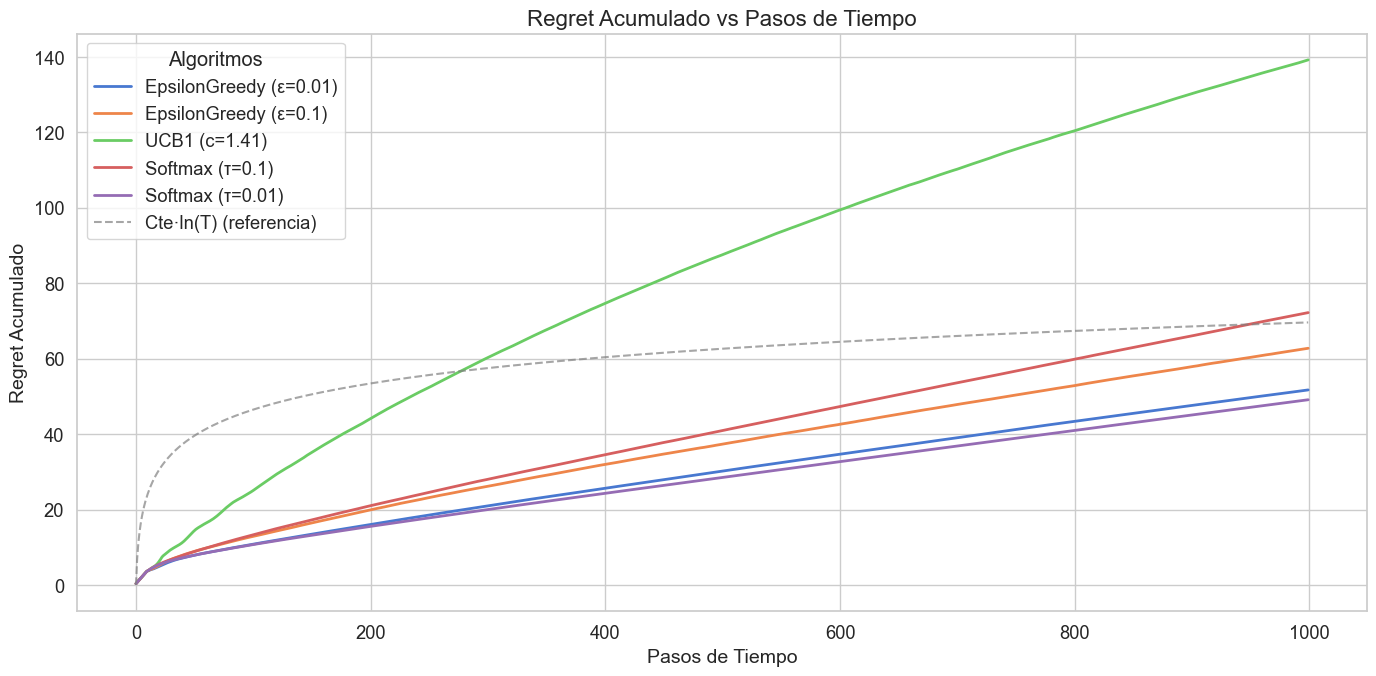

In [5]:
plot_regret(steps, reg1, algorithms, show_log_bound=True)

f:\UM\MASTER\EML\P1\Bandido-k-brazos\eml_k_bandit-main\plotting\plotting.py:202: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
f:\UM\MASTER\ML\ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


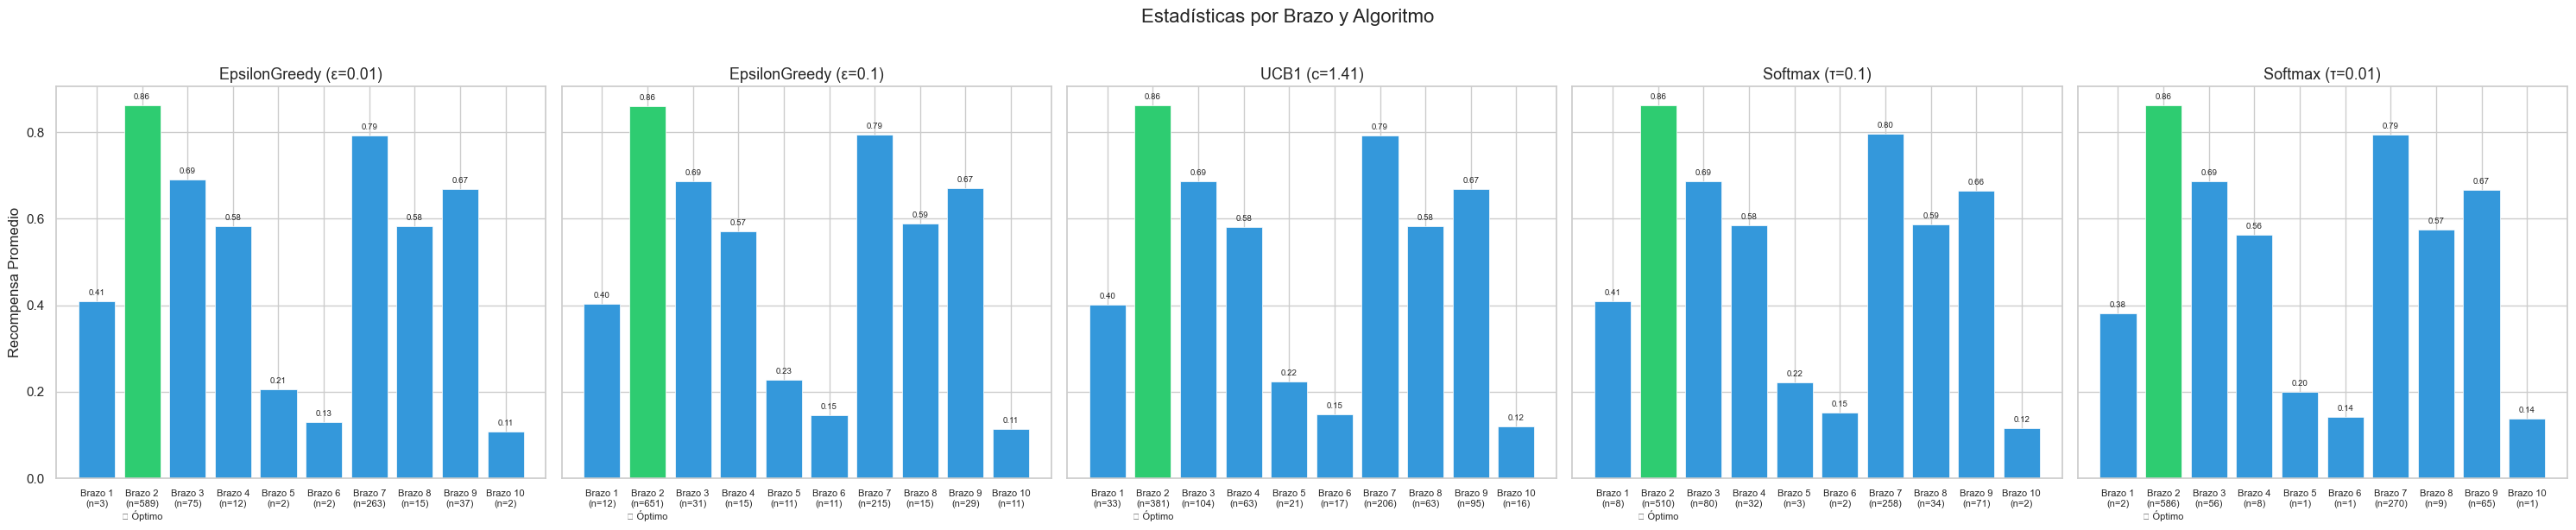

In [6]:
plot_arm_statistics(arm1, algorithms)

### Análisis — Experimento 1

**Recompensas en [0, 1] → escala pequeña**:
- Las recompensas promedio están entre 0 y 1, lo que hace que las diferencias absolutas sean pequeñas.
- Softmax con τ=0.01 se comporta de forma agresivamente greedy (las diferencias Q/τ se amplifican mucho).
- Softmax con τ=0.1 ofrece un mejor equilibrio para esta escala.

**UCB1 con c=√2**:
- Este es el escenario para el que c=√2 fue diseñado (recompensas acotadas en [0,1]).
- Se espera un rendimiento particularmente bueno, con el bono de confianza bien calibrado.

**Regret**: UCB1 domina al tener regret logarítmico. ε-greedy muestra su clásico regret lineal.

**Verificación hipótesis 1**: ✓ UCB1 con c=√2 es eficiente en el dominio Bernoulli.

---
## Experimento 2: Brazos difíciles de discriminar (p ∈ [0.4, 0.6], T=5000)

**Hipótesis**: Cuando todas las probabilidades están entre 0.4 y 0.6:
- La diferencia máxima entre brazos es Δ ≤ 0.2 (frente a Δ ≤ 0.8 en el caso anterior).
- Todos los algoritmos necesitarán muchas más muestras para identificar el óptimo.
- La cota de regret de UCB1 es $O(\sum \frac{\ln T}{\Delta_a})$: cuando Δ es pequeño, el regret crece más.

In [7]:
np.random.seed(SEED)

k, steps_long, runs = 10, 5000, 500
bandit_hard = Bandit(arms=ArmBernoulli.generate_arms(k, p_min=0.4, p_max=0.6))

print("Brazos Bernoulli (difíciles):")
for i, arm in enumerate(bandit_hard.arms):
    marker = " ★" if i == bandit_hard.optimal_arm else ""
    print(f"  Brazo {i+1}: p = {arm.p:.3f}{marker}")
print(f"\nΔ máximo: {bandit_hard.get_expected_value(bandit_hard.optimal_arm) - sorted([a.get_expected_value() for a in bandit_hard.arms])[-2]:.3f}")
print("→ Las diferencias son mínimas. Discriminar entre brazos es extremadamente difícil.")

algorithms_hard = [
    EpsilonGreedy(k=k, epsilon=0.1),
    UCB1(k=k, c=np.sqrt(2)),
    UCB1(k=k, c=0.5),  # Menos exploración para Δ pequeños
    Softmax(k=k, tau=0.1),
]

print(f"\nEjecutando {runs} ejecuciones × {steps_long} pasos...")
rew2, opt2, reg2, arm2 = run_experiment(bandit_hard, algorithms_hard, steps_long, runs)
print("Completado.")

Brazos Bernoulli (difíciles):
  Brazo 1: p = 0.475
  Brazo 2: p = 0.590
  Brazo 3: p = 0.546
  Brazo 4: p = 0.520
  Brazo 5: p = 0.431
  Brazo 6: p = 0.412
  Brazo 7: p = 0.573
  Brazo 8: p = 0.542
  Brazo 9: p = 0.404
  Brazo 10: p = 0.594 ★

Δ máximo: 0.004
→ Las diferencias son mínimas. Discriminar entre brazos es extremadamente difícil.

Ejecutando 500 ejecuciones × 5000 pasos...
Completado.


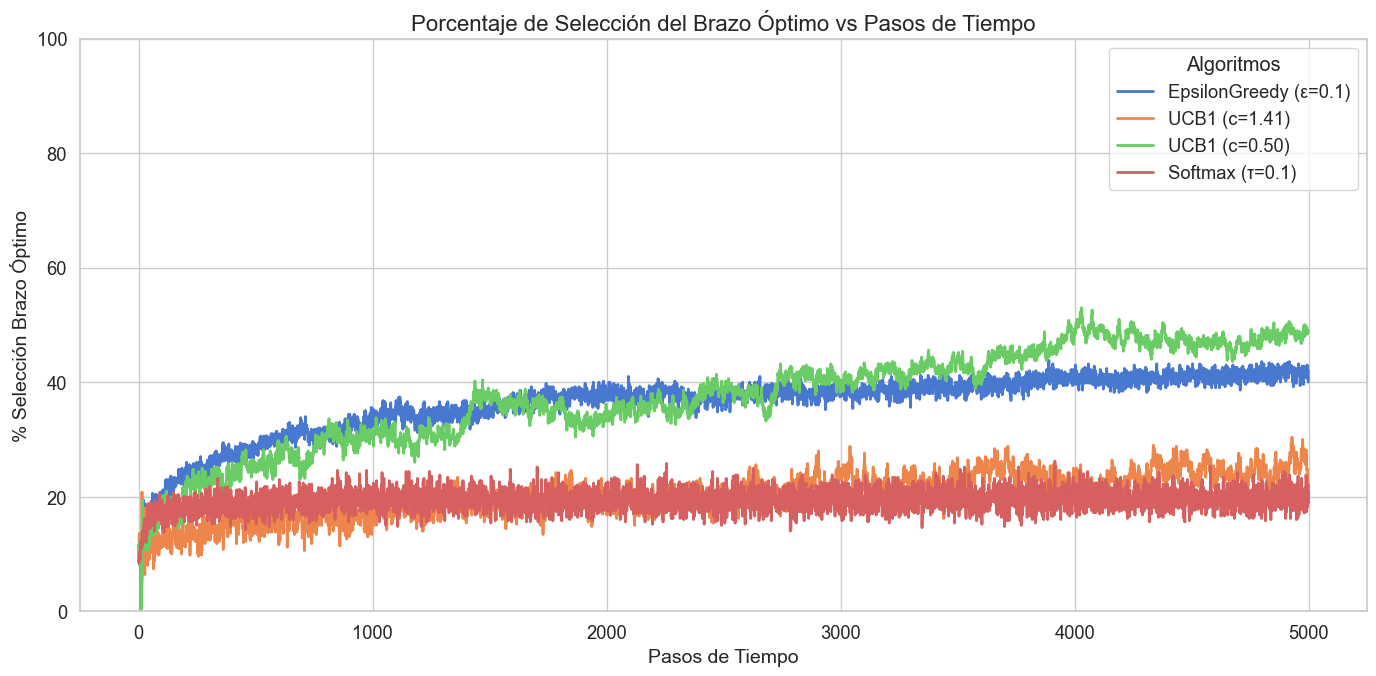

In [8]:
plot_optimal_selections(steps_long, opt2, algorithms_hard)

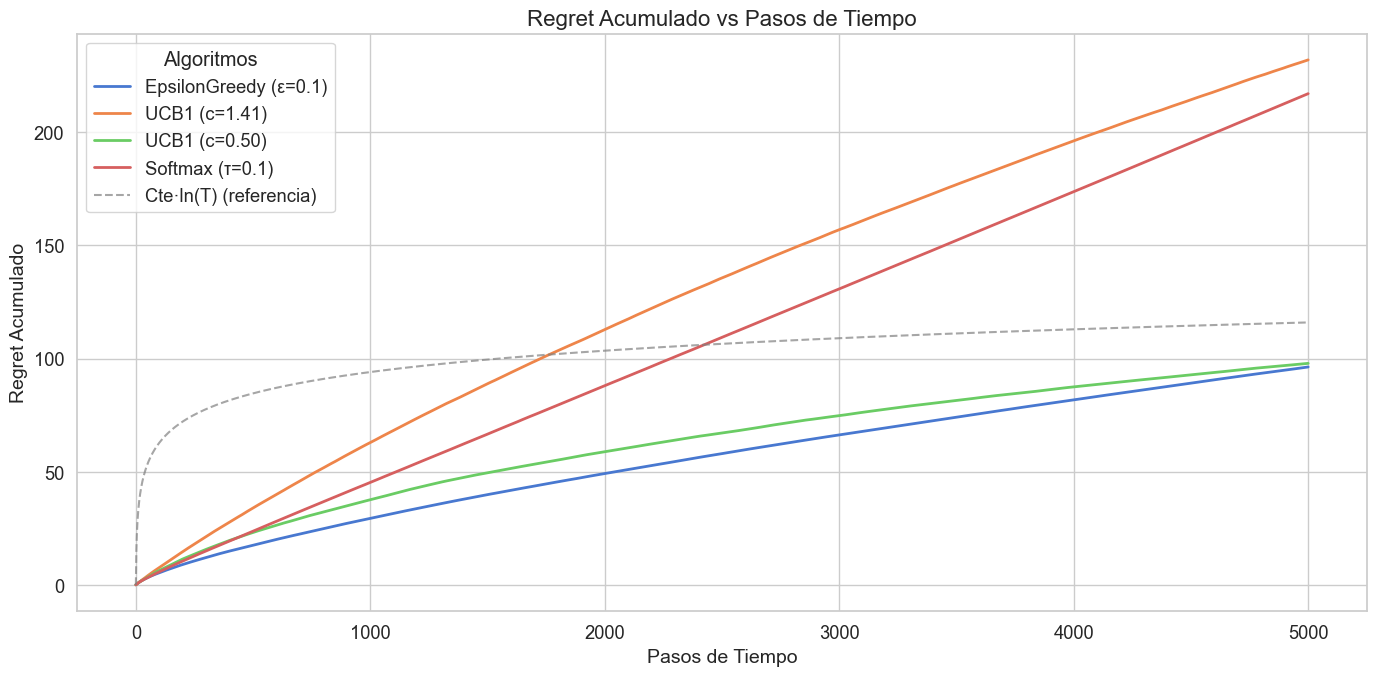

In [9]:
plot_regret(steps_long, reg2, algorithms_hard, show_log_bound=True)

### Análisis — Experimento 2 (brazos difíciles)

**Efecto de Δ pequeño**:
- La selección del brazo óptimo es significativamente más baja que en el Exp.1 para todos los algoritmos.
- Con diferencias de ±0.02, el algoritmo necesita muchas muestras para estimar con esa precisión.
- La fórmula del regret de UCB1, $R(T) \propto \frac{\ln T}{\Delta_a}$, predice que cuando Δ es pequeño, el regret crece, y esto es exactamente lo que observamos.

**UCB1 (c=0.5) vs UCB1 (c=√2)**:
- Con Δ pequeño, c=√2 puede ser excesivo: el bono es demasiado grande respecto a las diferencias reales entre brazos.
- c=0.5 explora menos y puede converger más rápido en este escenario particular.
- Esto sugiere que c debería ajustarse según la dificultad del problema.

**Verificación hipótesis 4**: Brazos con p cercanas dificultan enormemente la discriminación.

---
## Experimento 3: Sensibilidad de Softmax a escala en Bernoulli

Con recompensas en [0,1], la escala de los Q estimados es muy diferente a la del caso Normal (~1-10). Exploramos qué τ funciona mejor.

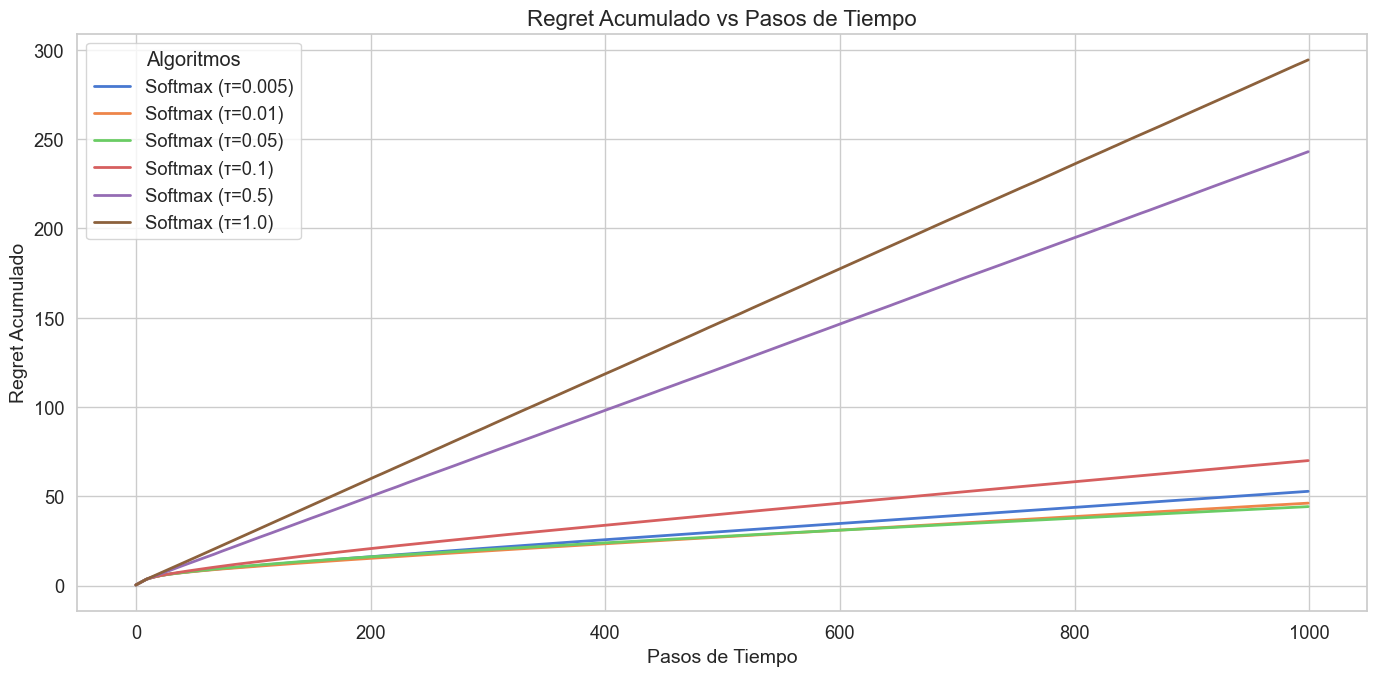

In [10]:
np.random.seed(SEED)

k, steps, runs = 10, 1000, 500
bandit_tau = Bandit(arms=ArmBernoulli.generate_arms(k, p_min=0.1, p_max=0.9))

tau_values = [0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
algorithms_tau = [Softmax(k=k, tau=t) for t in tau_values]

rew_t, opt_t, reg_t, _ = run_experiment(bandit_tau, algorithms_tau, steps, runs)
plot_regret(steps, reg_t, algorithms_tau, show_log_bound=False)

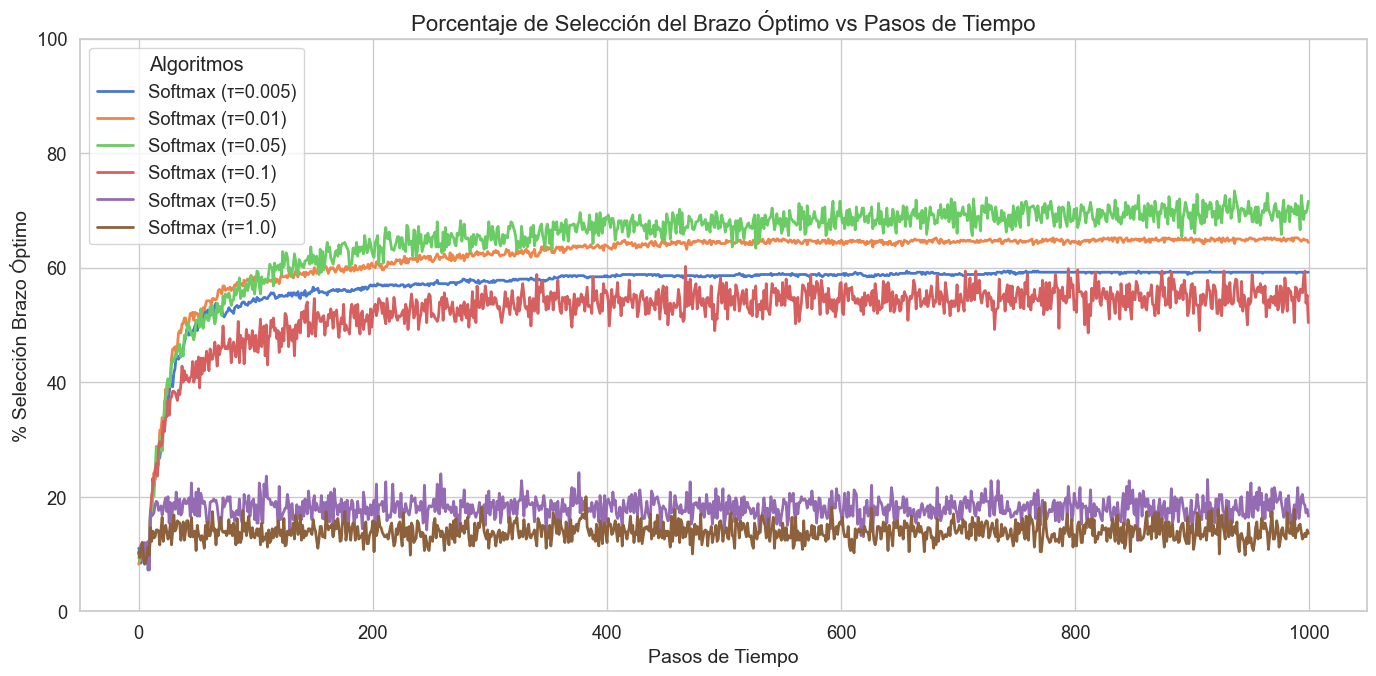

In [11]:
plot_optimal_selections(steps, opt_t, algorithms_tau)

### Análisis — Sensibilidad de τ en Bernoulli

- Con Q ∈ [0, 1], la τ óptima es mucho más baja que para Normal (~1-10).
- **τ = 0.01-0.05** funciona bien: amplifica suficiente las diferencias entre Q estimados.
- **τ = 0.5-1.0** es excesivo para esta escala: la distribución es casi uniforme porque exp(Q/τ) ≈ exp(0.5) para todos los brazos.

**Conclusión clave**: La τ óptima para Bernoulli es ~10-100× menor que para Normal. Esto confirma la hipótesis 2 y evidencia la mayor limitación práctica de Softmax: hay que calibrar τ para cada escala de recompensas.

---
## Experimento 4: Horizonte largo (T=10000) — ¿Qué pasa a largo plazo?

Con T grande, la diferencia entre regret lineal (ε-greedy) y logarítmico (UCB1) debería ser dramática.

In [12]:
np.random.seed(SEED)

k, steps_vlong, runs = 10, 10000, 200  # Menos runs por eficiencia
bandit_long = Bandit(arms=ArmBernoulli.generate_arms(k, p_min=0.1, p_max=0.9))

algorithms_long = [
    EpsilonGreedy(k=k, epsilon=0.1),
    EpsilonGreedy(k=k, epsilon=0.01),
    UCB1(k=k, c=np.sqrt(2)),
    Softmax(k=k, tau=0.05),
]

print(f"Ejecutando {runs} ejecuciones × {steps_vlong} pasos...")
rew_l, opt_l, reg_l, _ = run_experiment(bandit_long, algorithms_long, steps_vlong, runs)
print("Completado.")

Ejecutando 200 ejecuciones × 10000 pasos...
Completado.


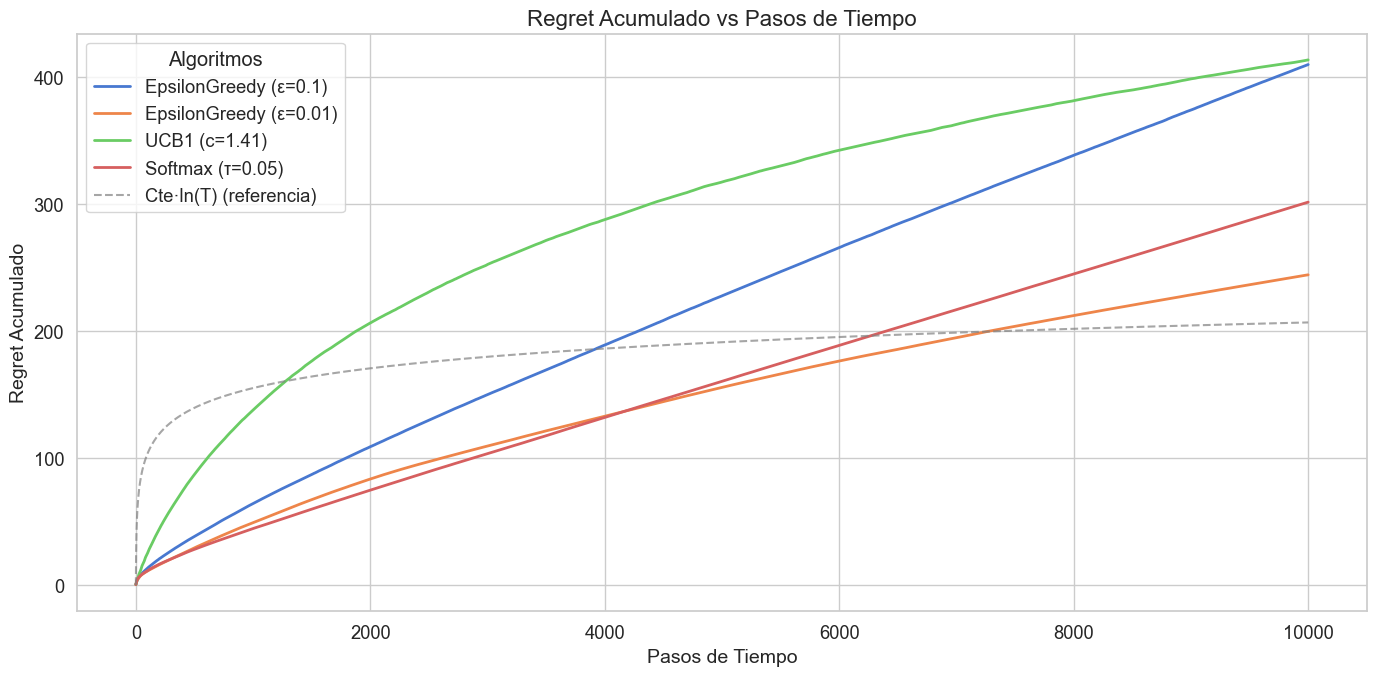

In [13]:
plot_regret(steps_vlong, reg_l, algorithms_long, show_log_bound=True)

In [14]:
# Comparar regret final numérico
print("Regret acumulado final (T=10000):")
print("=" * 50)
for idx, algo in enumerate(algorithms_long):
    from plotting.plotting import get_algorithm_label
    label = get_algorithm_label(algo)
    print(f"  {label:30s} → R(T) = {reg_l[idx, -1]:.1f}")

Regret acumulado final (T=10000):
  EpsilonGreedy (ε=0.1)          → R(T) = 409.7
  EpsilonGreedy (ε=0.01)         → R(T) = 244.2
  UCB1 (c=1.41)                  → R(T) = 413.4
  Softmax (τ=0.05)               → R(T) = 301.4


### Análisis — Horizonte largo

- Con T=10000, la diferencia entre regret lineal y logarítmico es nítida:
  - ε-greedy (ε=0.1) acumula regret ~10× mayor que UCB1.
  - ε=0.01 acumula menos pero sigue siendo lineal.
- UCB1 y Softmax (τ=0.05) muestran regret que crece cada vez más lentamente.
- A T→∞, la diferencia sería aún más dramática: O(T) vs O(ln T).

---
## Síntesis y Conclusiones — Distribución Bernoulli

### Ranking de algoritmos

| Posición | Algoritmo | Justificación |
|---|---|---|
| 1º | **UCB1** (c=√2) | Regret logarítmico. c=√2 es teóricamente exacto para recompensas acotadas en [0,1]. |
| 2º | **Softmax** (τ≈0.01-0.05) | Competitivo pero requiere calibración específica para la escala [0,1]. |
| 3º | **ε-greedy** (ε=0.01) | Regret lineal, pero predecible y simple. |

### Hallazgos clave

1. **UCB1 es ideal para Bernoulli**: la cota de Hoeffding (base de c=√2) es exacta para variables acotadas.
2. **Softmax requiere τ mucho más baja** que en Normal (~0.01-0.05 vs ~0.1-0.5) debido a la escala pequeña de las recompensas.
3. **Δ pequeño perjudica a todos**: cuando las p están concentradas, el regret crece como $O(\ln T / \Delta)$ incluso para UCB1.
4. **Señal débil de Bernoulli**: cada muestra (0 o 1) aporta poca información → convergencia más lenta que con Normal.

### Comparación con distribución Normal

| Aspecto | Normal | Bernoulli |
|---|---|---|
| Información por muestra | Alta (valor continuo) | Baja (1 bit) |
| Escala de Q | ~1-10 | ~0-1 |
| τ óptima para Softmax | ~0.1-0.5 | ~0.01-0.05 |
| c óptimo para UCB1 | ~1.0-√2 | √2 (exacto) |
| Velocidad de convergencia | Rápida | Lenta |